In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from data_processing.loading.dataframe_loading import load_psd
from data_processing.arc_paths import get_parq_root, get_report_root, INPUT_DATA_FOLDER
from data_processing.processing.bimodal_fitting import (
    get_psd_energy_histogram, 
    scan_histogram_slices
)
from data_processing.reporting.plotting import plot_psd_histogram, plot_scatter
from data_processing.dataframe_validation import get_df_col, DataframeColumn

from scipy.signal import savgol_filter, find_peaks
from scipy.interpolate import UnivariateSpline

In [2]:
# Data location

experiment_name = 'ID-56'
experiment_display_name = 'EJ-309 Magnetic Interference Testing - Inside reactor room, no shield'

In [3]:
# Locations
PARQ_ROOT = get_parq_root(experiment_name)
REPORT_ROOT = get_report_root(experiment_name)

In [4]:
# read first csv into dataframe
# get header from first csv
psd_report = load_psd(experiment_name)

In [5]:
psd_report.head()

,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total
0,0.177720,228,250,6155455480,0.088000
1,0.070217,88,96,12323457608,0.083333
2,0.287316,360,407,50701536167,0.115479
3,1.051700,1299,1502,51979858175,0.135153
4,0.171437,219,241,72854797651,0.091286


In [6]:
energy_spectrum_path = INPUT_DATA_FOLDER / experiment_name / "processed_data/unfiltered/spectra/energy_spectrum_0.parquet"

In [7]:
energy_spectrum = pd.read_parquet(energy_spectrum_path)
energy_spectrum

,channel,count,bin_energy
0,0.0,0,0.003202
1,1.0,1,0.003900
2,2.0,0,0.004598
3,3.0,0,0.005296
4,4.0,0,0.005994
...,...,...,...
4090,4090.0,0,2.858310
4091,4091.0,0,2.859010
4092,4092.0,0,2.859700
4093,4093.0,0,2.860400


In [8]:
energy_channel_array = energy_spectrum['channel']
bin_energy_array = energy_spectrum['bin_energy']

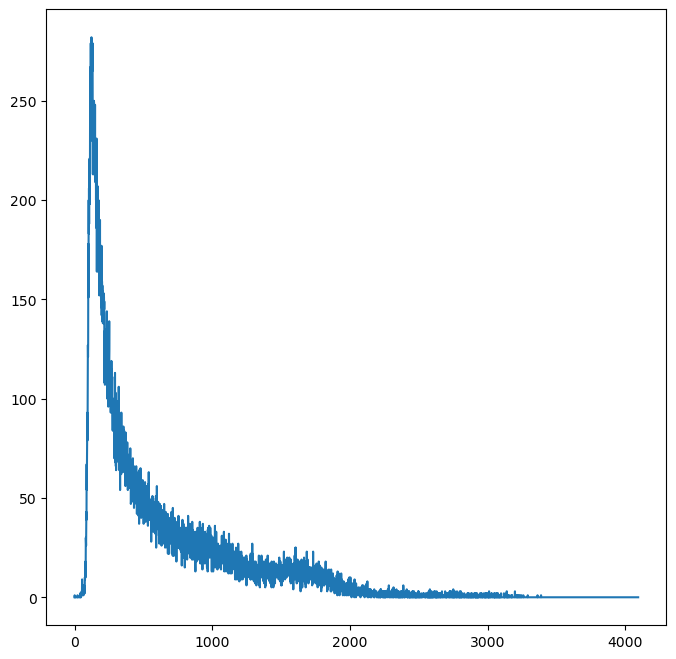

In [9]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_channel_array, energy_spectrum['count'])

In [10]:
energy_spectrum_smooth = savgol_filter(energy_spectrum['count'], 51, 7)

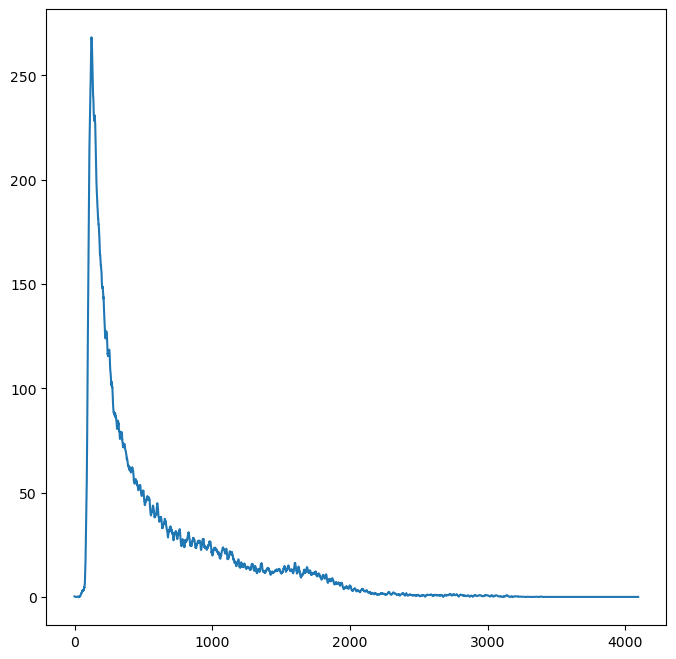

In [11]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_channel_array, energy_spectrum_smooth)

In [12]:
energy_spectrum_deriv = np.gradient(energy_spectrum_smooth)

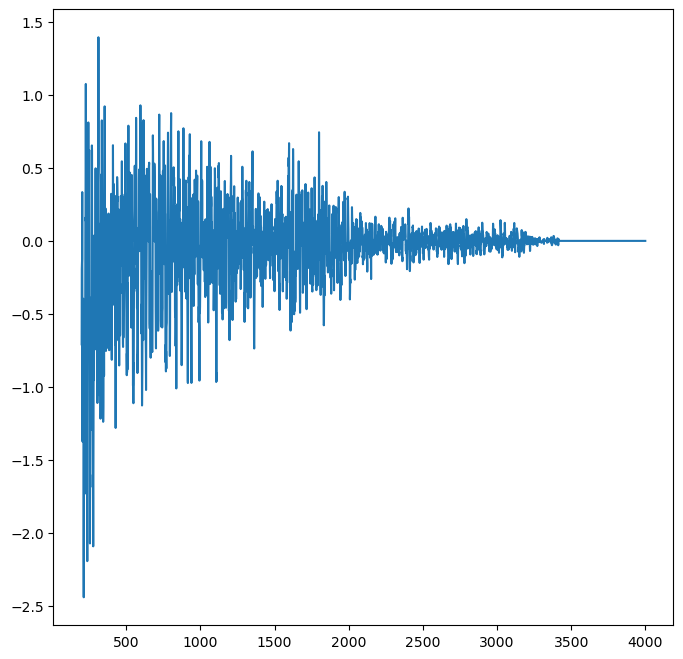

In [13]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(energy_channel_array[200:4000], energy_spectrum_deriv[200:4000])

In [14]:
energy_spectrum_spline = UnivariateSpline(bin_energy_array, energy_spectrum_smooth)
energy_spectrum_spline_array = energy_spectrum_spline(bin_energy_array)
energy_spectrum_spline_deriv = energy_spectrum_spline.derivative()
energy_spectrum_spline_deriv_array = energy_spectrum_spline_deriv(bin_energy_array)

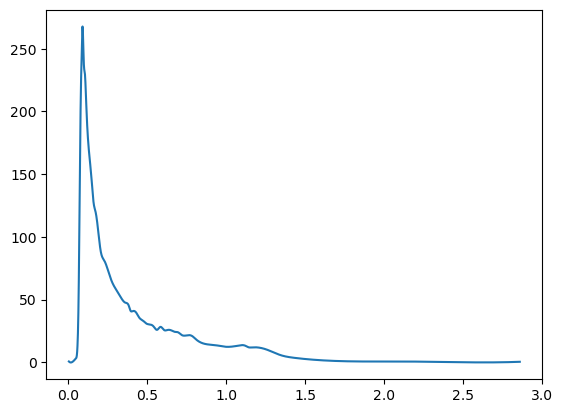

In [15]:
plt.plot(bin_energy_array, energy_spectrum_spline_array)

In [16]:
# peak finding
peaks, properties = find_peaks(-energy_spectrum_spline_deriv(bin_energy_array))
peaks

array([  64,  114,  131,  156,  211,  268,  360,  460,  550,  625,  686,
        777,  852,  940, 1010, 1142, 1371, 1613, 1853, 3387])

In [17]:
# peak finding
peaks, properties = find_peaks(-energy_spectrum_spline_deriv(bin_energy_array), width=100, prominence=4)
print(peaks)
print(properties['prominences'])
print(properties['widths'])

[1142 1853]
[143.39120047  58.77638243]
[100.6594968  236.08594022]


In [18]:
compton_edge = bin_energy_array[peaks[-1]]

Text(1.30673, 100, 'Compton Edge: 1.29673 MeVee')

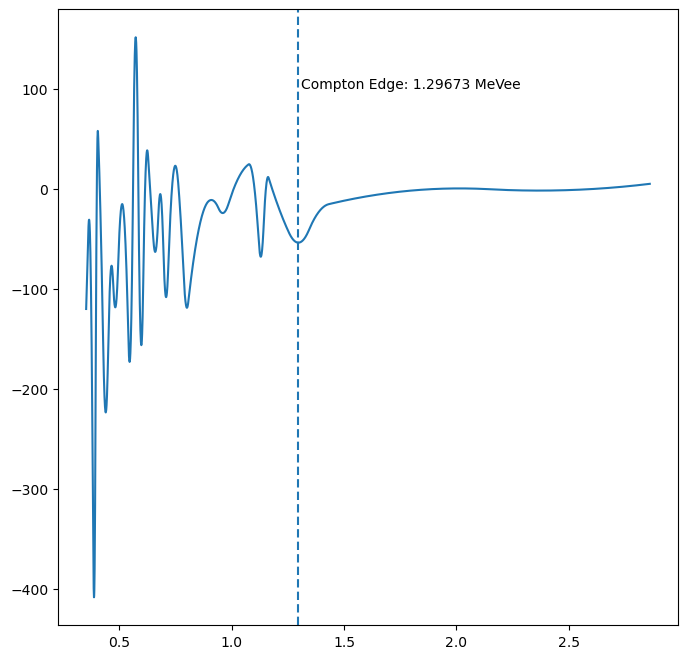

In [19]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array[500:], energy_spectrum_spline_deriv_array[500:])
ax.axvline(compton_edge, dashes=[4,2])
ax.text(compton_edge + 0.01, 100, f"Compton Edge: {compton_edge} MeVee")

Text(1.31673, 250, 'Compton Edge: 1.29673 MeVee')

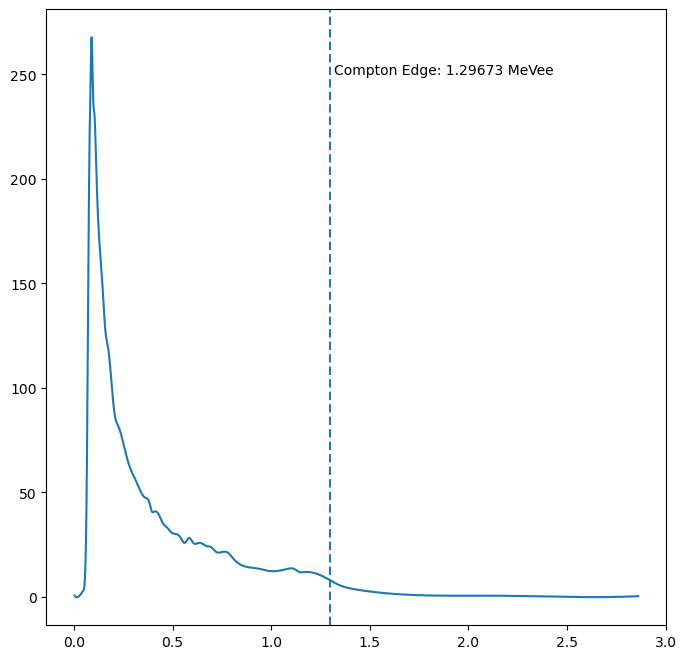

In [20]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum_spline_array)
ax.axvline(compton_edge, dashes=[4,2])
ax.text(compton_edge + 0.02, 250, f"Compton Edge: {compton_edge} MeVee")

(0.0, 40.0)

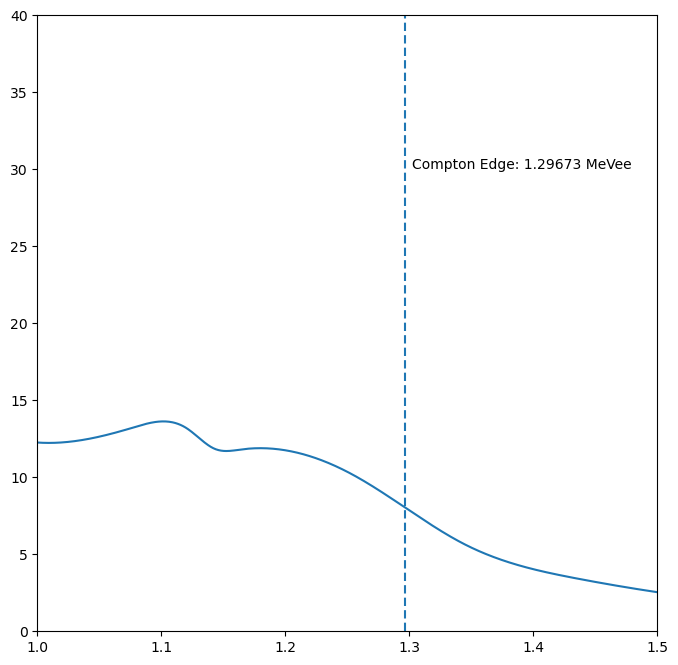

In [21]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum_spline_array)
ax.axvline(compton_edge, dashes=[4,2])
ax.text(compton_edge + 0.005, 30, f"Compton Edge: {compton_edge} MeVee")
ax.set_xlim(1.0, 1.5)
ax.set_ylim(0, 40)

In [22]:
# Using spline on raw data
energy_spectrum_raw_spline = UnivariateSpline(bin_energy_array, energy_spectrum["count"], s=16*len(bin_energy_array))
energy_spectrum_raw_spline_array = energy_spectrum_raw_spline(bin_energy_array)
print(f"Smoothing factor: {16*len(bin_energy_array)}")

Smoothing factor: 65520


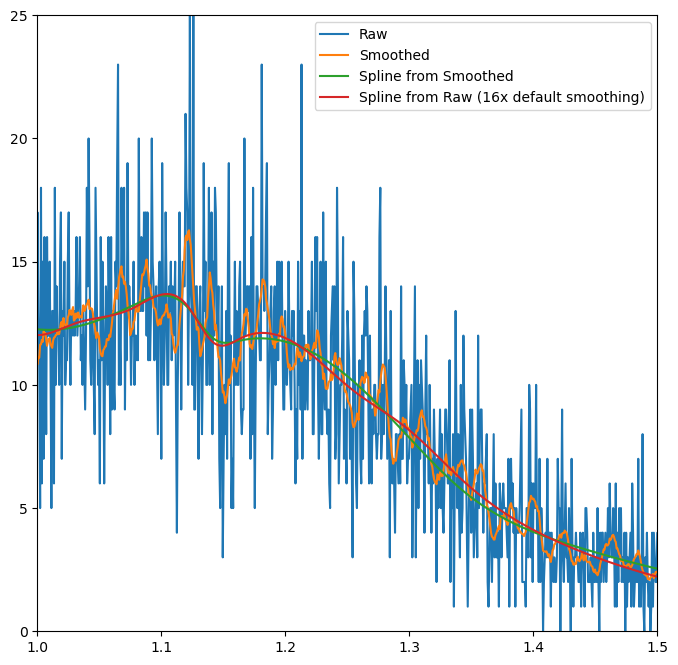

In [23]:
# comparing spline on smoothed vs raw data
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum['count'], label="Raw")
ax.plot(bin_energy_array, energy_spectrum_smooth, label="Smoothed")
ax.plot(bin_energy_array, energy_spectrum_spline_array, label="Spline from Smoothed")
ax.plot(bin_energy_array, energy_spectrum_raw_spline_array, label="Spline from Raw (16x default smoothing)")
ax.set_xlim(1.0, 1.5)
ax.set_ylim(0, 25)
ax.legend()

# No real shifts shown

In [24]:
energy_spectrum_raw_spline_deriv = energy_spectrum_raw_spline.derivative()
energy_spectrum_raw_spline_deriv_array = energy_spectrum_raw_spline_deriv(bin_energy_array)

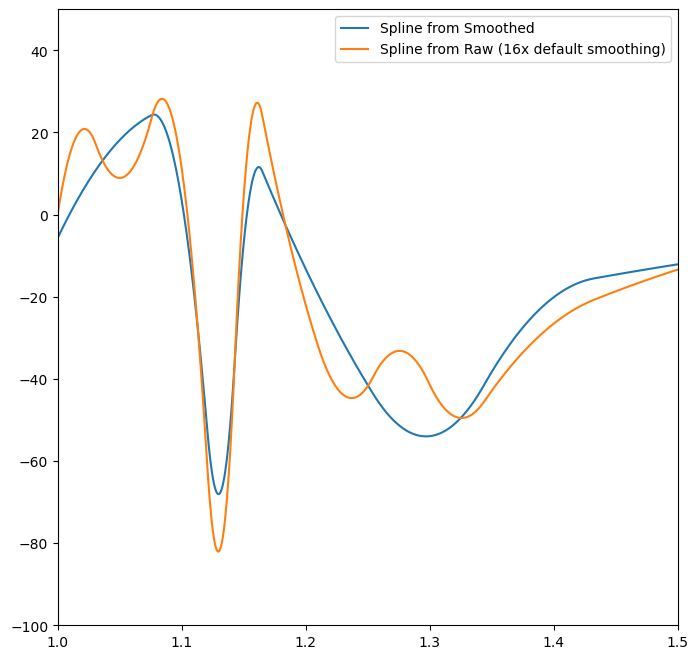

In [25]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(bin_energy_array, energy_spectrum_spline_deriv_array, label="Spline from Smoothed")
ax.plot(bin_energy_array, energy_spectrum_raw_spline_deriv_array, label="Spline from Raw (16x default smoothing)")
ax.set_xlim(1.0, 1.5)
ax.set_ylim(-100, 50)
ax.legend()

In [26]:
all_exp_details = {
    "ID-56": "Inside, no shield",
    "ID-57": "Inside, with shield",
    "ID-58": "Inside, with shield + wall plate",
    "ID-59": "Outside, with shield",
    "ID-60": "Outside, no shield",
#     "ID-61": "Reactor installed, no shield",
    "ID-62": "Reactor installed, with wall plate",
    "ID-63": "Reactor installed, with shield",
    "ID-64": "Reactor installed, with shield and wall plate",
    "ID-65": "Reactor installed, with wall plate (run 2)",
    "ID-66": "Reactor installed, with shield and NEW wall plate",
    "ID-67": "Reactor ON, with shield and NEW wall plate",
}
experiment_spectra_paths = {exp_name:INPUT_DATA_FOLDER / exp_name / "processed_data/unfiltered/spectra/energy_spectrum_0.parquet" 
                            for exp_name in all_exp_details}

In [27]:
all_energy_spectra = {exp_name: pd.read_parquet(spectra_path) for exp_name, spectra_path in experiment_spectra_paths.items()}

In [49]:
smoothed_plot_data = {}
for exp_name, energy_spectrum in all_energy_spectra.items():
    bin_energy_array = energy_spectrum['bin_energy']
    energy_spectrum_smooth = savgol_filter(energy_spectrum['count'], 51, 7)
    energy_spectrum_spline = UnivariateSpline(bin_energy_array, energy_spectrum_smooth)
    energy_spectrum_spline_deriv = energy_spectrum_spline.derivative()
    peaks, _ = find_peaks(-energy_spectrum_spline_deriv(bin_energy_array), width=100, prominence=4)
    print(f"{exp_name}: Peaks at indices {peaks}, corresponding to energies {[bin_energy_array[peak] for peak in peaks]}")
    compton_edge = bin_energy_array[peaks[-1]]
    smoothed_plot_data[exp_name] = {
        "x": bin_energy_array,
        "y": energy_spectrum_spline(bin_energy_array),
        "y_deriv": energy_spectrum_spline_deriv(bin_energy_array),
        "compton_edge": compton_edge,
        "exp_description": all_exp_details[exp_name]
    }

ID-56: Peaks at indices [1142 1853], corresponding to energies [0.800398, 1.29673]
ID-57: Peaks at indices [1140 1879], corresponding to energies [0.799002, 1.31488]
ID-58: Peaks at indices [1955], corresponding to energies [1.36793]
ID-59: Peaks at indices [1165 2021], corresponding to energies [0.816454, 1.414]
ID-60: Peaks at indices [1827], corresponding to energies [1.27858]
ID-62: Peaks at indices [1746], corresponding to energies [1.22203]
ID-63: Peaks at indices [988], corresponding to energies [0.692895]
ID-64: Peaks at indices [1041 1227 1964], corresponding to energies [0.729893, 0.859734, 1.37421]
ID-65: Peaks at indices [ 859 1652], corresponding to energies [0.602844, 1.15641]
ID-66: Peaks at indices [1099 1645 1900], corresponding to energies [0.770381, 1.15153, 1.32953]
ID-67: Peaks at indices [1065 1347 1904], corresponding to energies [0.746647, 0.943502, 1.33233]


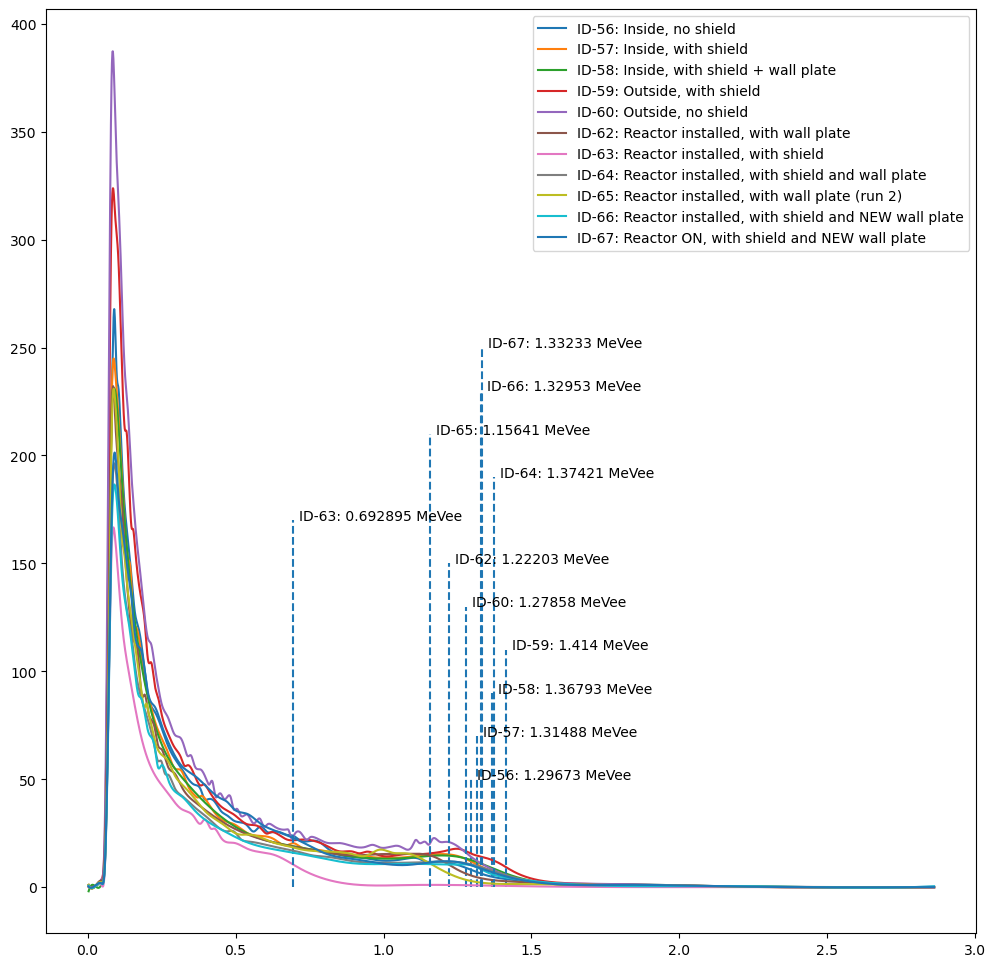

In [30]:
fig, ax = plt.subplots(figsize=(12,12))
for i, (exp_name, plot_series) in enumerate(plot_data.items()):
    ax.plot(plot_series['x'], plot_series['y'], label=f"{exp_name}: {plot_series['exp_description']}")
    compton_edge = plot_series['compton_edge']
    ax.vlines([compton_edge], linestyle="dashed", ymin=0, ymax=50+i*20)
    ax.text(compton_edge + 0.02, 50+i*20, f"{exp_name}: {compton_edge} MeVee")
ax.legend()

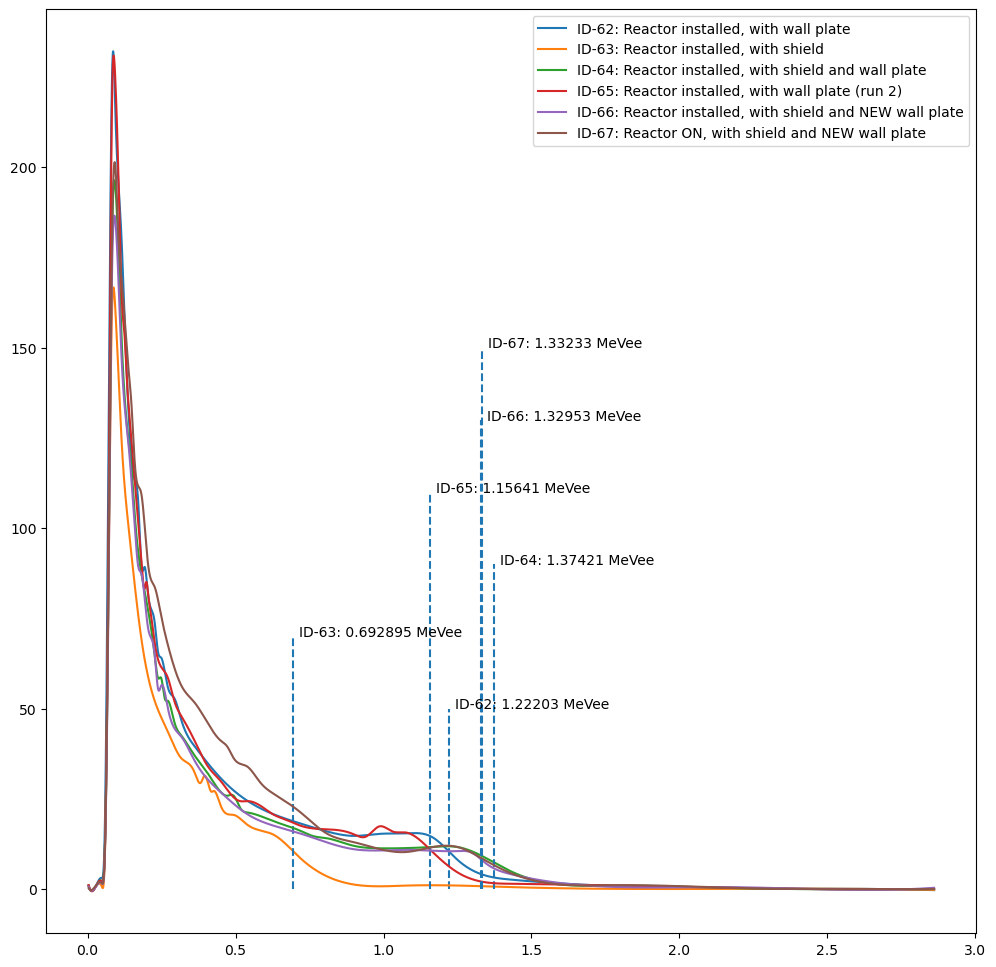

In [31]:
plot_data_batch_2 = {k: v for k, v in plot_data.items() if k in [f"ID-{x}" for x in range(62, 68)]}

fig, ax = plt.subplots(figsize=(12,12))
for i, (exp_name, plot_series) in enumerate(plot_data_batch_2.items()):
    ax.plot(plot_series['x'], plot_series['y'], label=f"{exp_name}: {plot_series['exp_description']}")
    compton_edge = plot_series['compton_edge']
    ax.vlines([compton_edge], linestyle="dashed", ymin=0, ymax=50+i*20)
    ax.text(compton_edge + 0.02, 50+i*20, f"{exp_name}: {compton_edge} MeVee")
ax.legend()

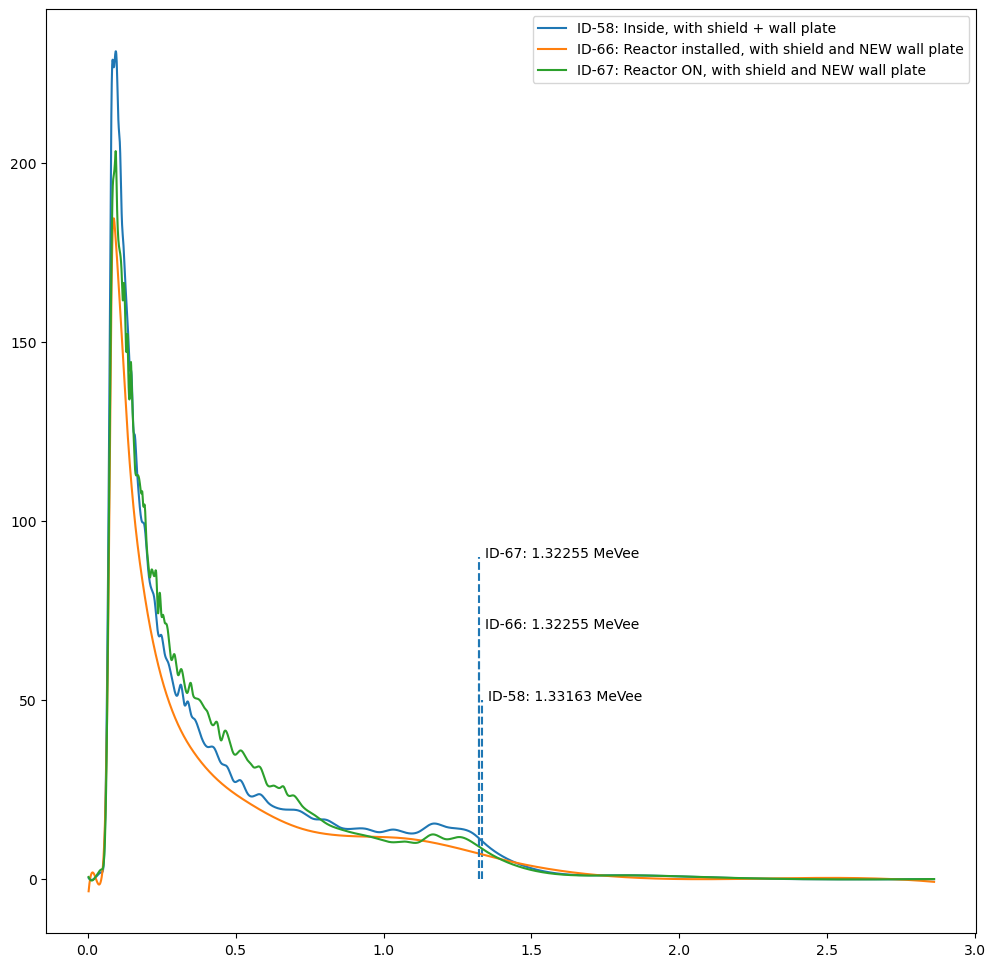

In [50]:
# Effect of reactor status (uninstalled, installed, on) on compton edge, shielding installed
plot_data_batch_3 = {k: v for k, v in plot_data.items() if k in [f"ID-{x}" for x in [58, 66, 67]]}

fig, ax = plt.subplots(figsize=(12,12))
for i, (exp_name, plot_series) in enumerate(plot_data_batch_3.items()):
    ax.plot(plot_series['x'], plot_series['y'], label=f"{exp_name}: {plot_series['exp_description']}")
    compton_edge = plot_series['compton_edge']
    ax.vlines([compton_edge], linestyle="dashed", ymin=0, ymax=50+i*20)
    ax.text(compton_edge + 0.02, 50+i*20, f"{exp_name}: {compton_edge} MeVee")
ax.legend()

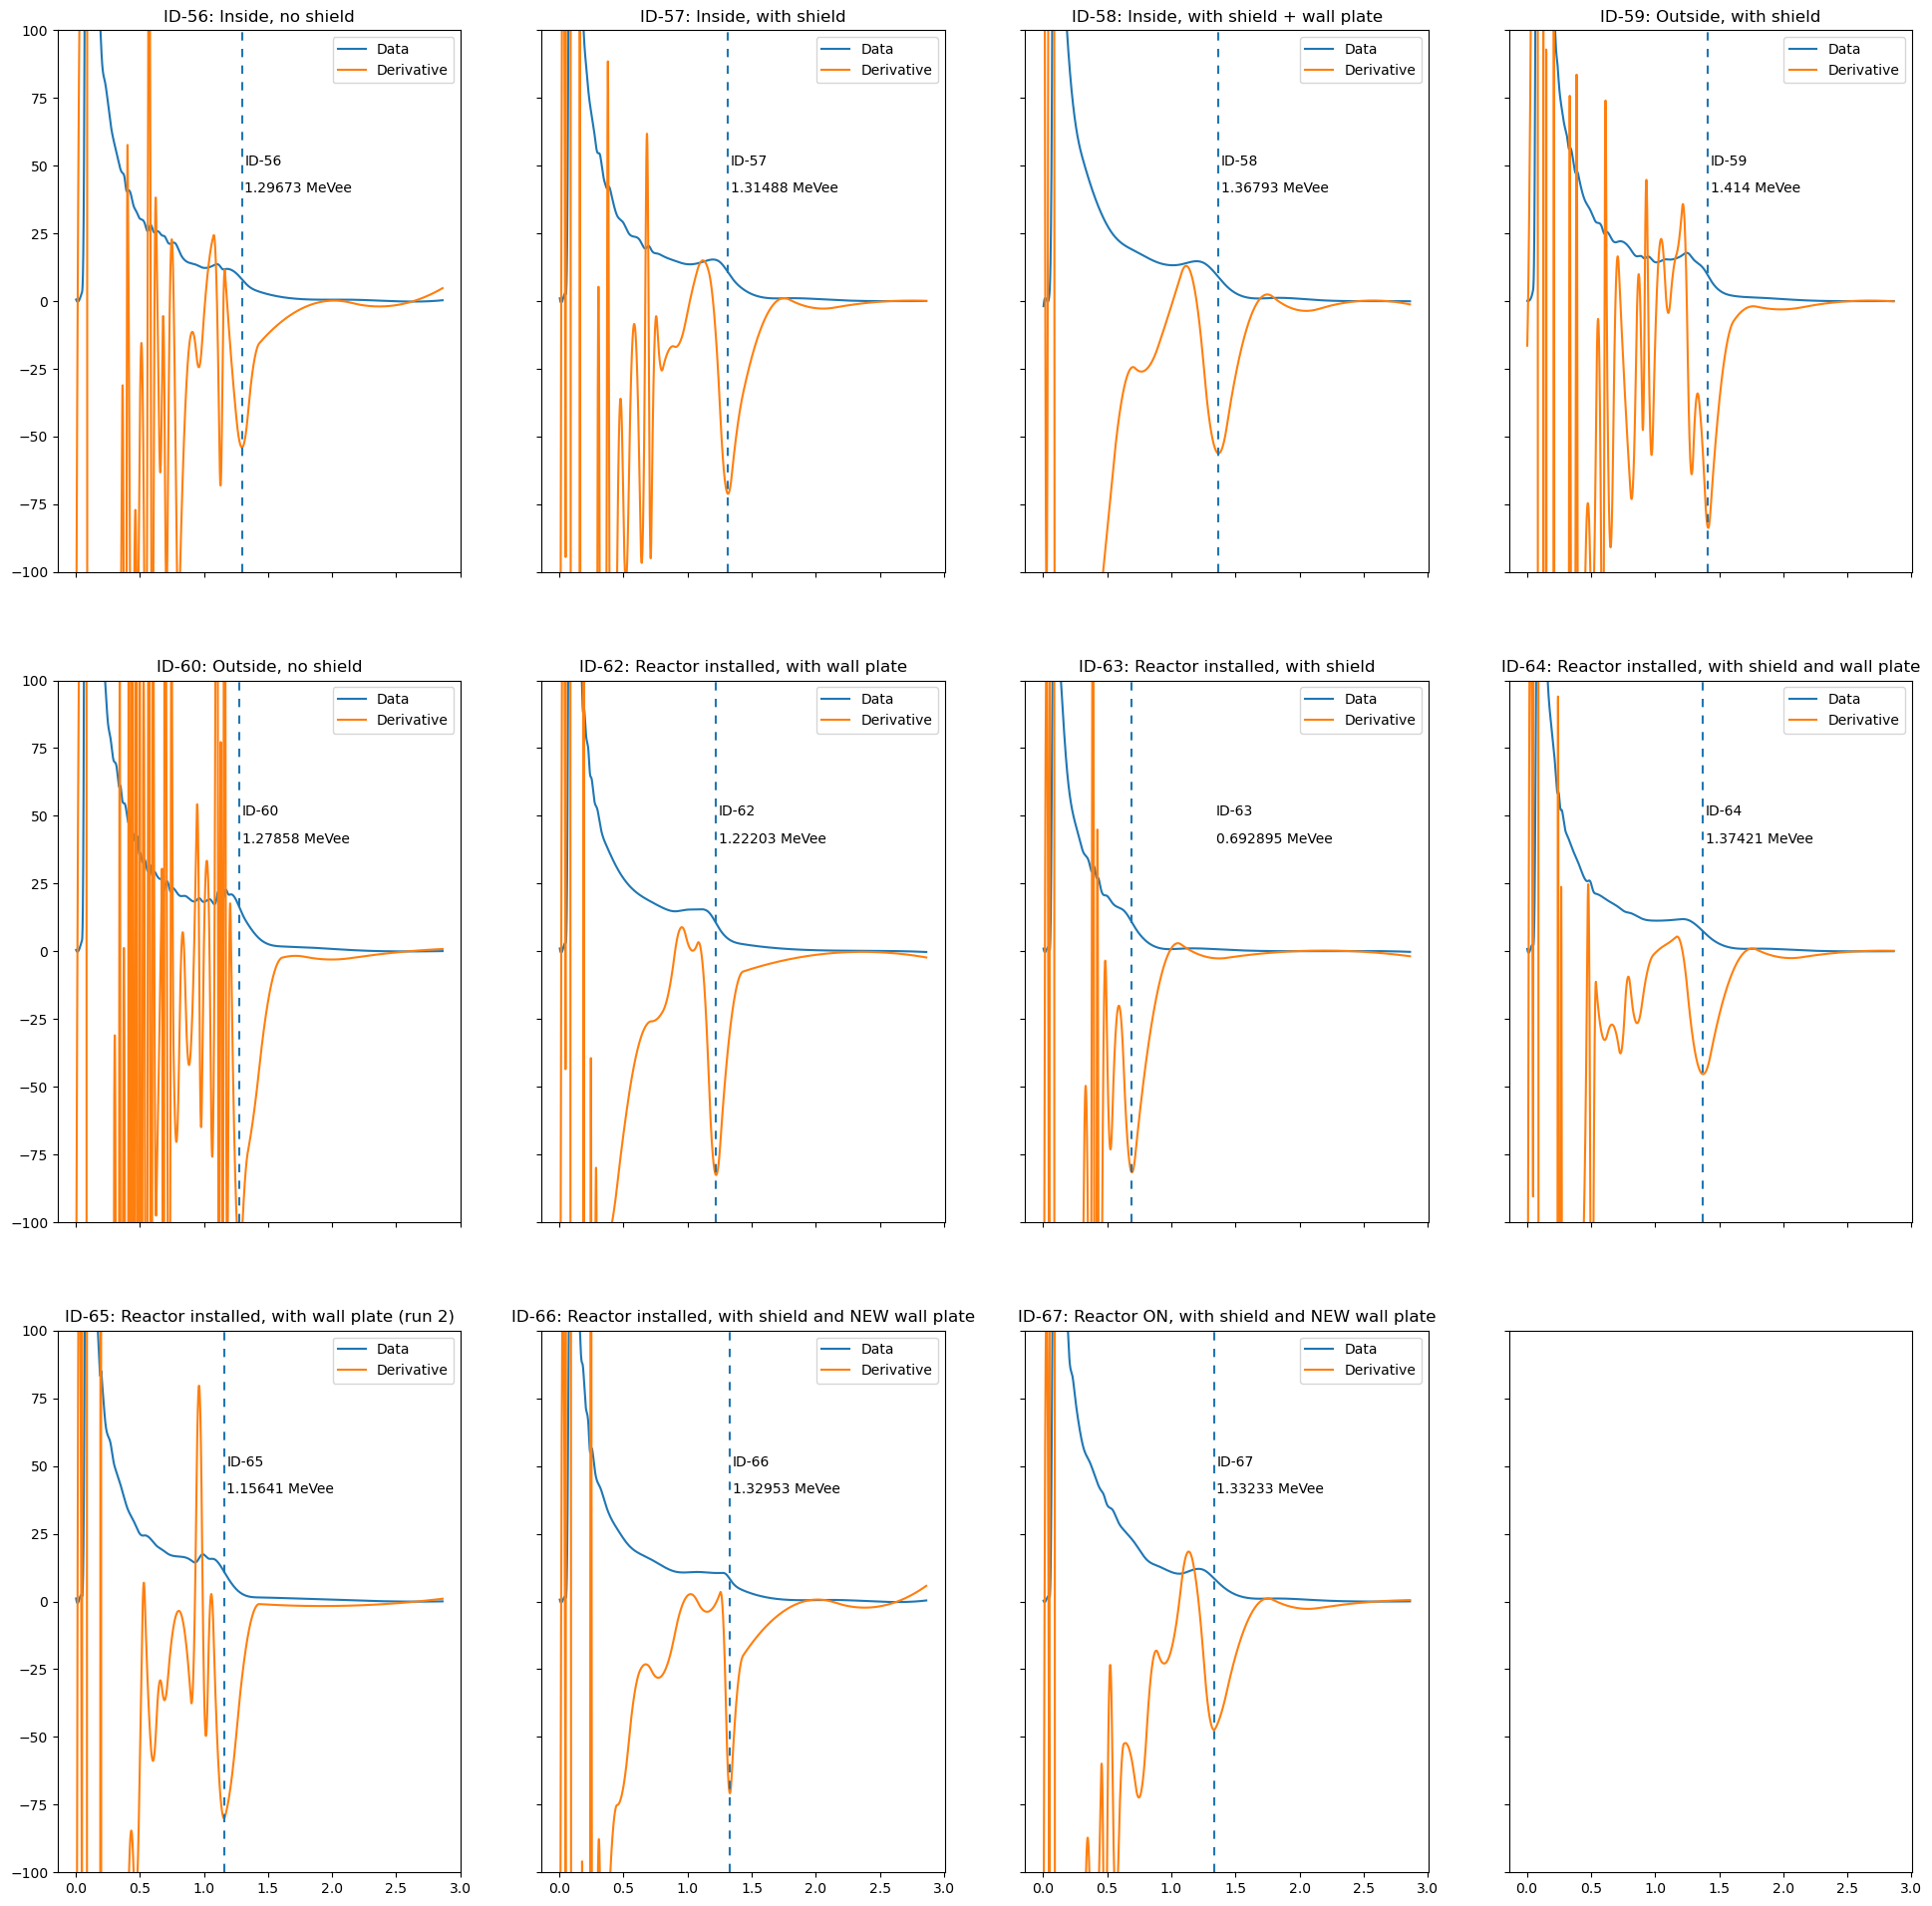

In [53]:
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(24,24))
row1, row2, row3 = axs
all_axs = [*row1, *row2, *row3]
for i, (exp_name, plot_series) in enumerate(smoothed_plot_data.items()):
    ax = all_axs[i]
    ax.set_title(f"{exp_name}: {plot_series['exp_description']}")
    ax.plot(plot_series['x'], plot_series['y'], label="Data")
    ax.plot(plot_series['x'], plot_series['y_deriv'], label="Derivative")
    compton_edge = plot_series['compton_edge']
    ax.axvline(compton_edge, ymin=0, ymax=1, dashes=(4,4))
    text_x = compton_edge + 0.02 if 1.0<compton_edge<1.45 else 1.35
    text_y = 50
    ax.text(text_x, text_y, f"{exp_name}")
    ax.text(text_x, text_y - 10, f"{compton_edge} MeVee")
    ax.set_ylim(-100, 100)
#     ax.set_xlim(1.0, 1.5)
    ax.legend()

In [48]:
# re-run analysis using raw splines
plot_data = {}
for exp_name, energy_spectrum in all_energy_spectra.items():
    bin_energy_array = energy_spectrum['bin_energy']
#     energy_spectrum_smooth = savgol_filter(energy_spectrum['count'], 51, 7)
    energy_spectrum_spline = UnivariateSpline(bin_energy_array, energy_spectrum['count'], s=16*len(bin_energy_array))
    energy_spectrum_spline_deriv = energy_spectrum_spline.derivative()
    peaks, _ = find_peaks(-energy_spectrum_spline_deriv(bin_energy_array), width=100, prominence=4)
    print(f"{exp_name}: Peaks at indices {peaks}, corresponding to energies {[bin_energy_array[peak] for peak in peaks]}")
    compton_edge = bin_energy_array[peaks[-1]]
    plot_data[exp_name] = {
        "x": bin_energy_array,
        "y": energy_spectrum_spline(bin_energy_array),
        "y_deriv": energy_spectrum_spline_deriv(bin_energy_array), 
        "compton_edge": compton_edge,
        "exp_description": all_exp_details[exp_name]
    }

ID-56: Peaks at indices [1894], corresponding to energies [1.32535]
ID-57: Peaks at indices [ 668 1505 1894], corresponding to energies [0.469513, 1.0538, 1.32535]
ID-58: Peaks at indices [1903], corresponding to energies [1.33163]
ID-59: Peaks at indices [1364 2029], corresponding to energies [0.955369, 1.41959]
ID-60: Peaks at indices [2992], corresponding to energies [2.09183]
ID-62: Peaks at indices [1022 1751], corresponding to energies [0.71663, 1.22552]
ID-63: Peaks at indices [193], corresponding to energies [0.13793]
ID-64: Peaks at indices [1895], corresponding to energies [1.32604]
ID-65: Peaks at indices [ 936 1208 1681], corresponding to energies [0.656596, 0.846471, 1.17666]
ID-66: Peaks at indices [ 162 1890], corresponding to energies [0.116289, 1.32255]
ID-67: Peaks at indices [1890], corresponding to energies [1.32255]


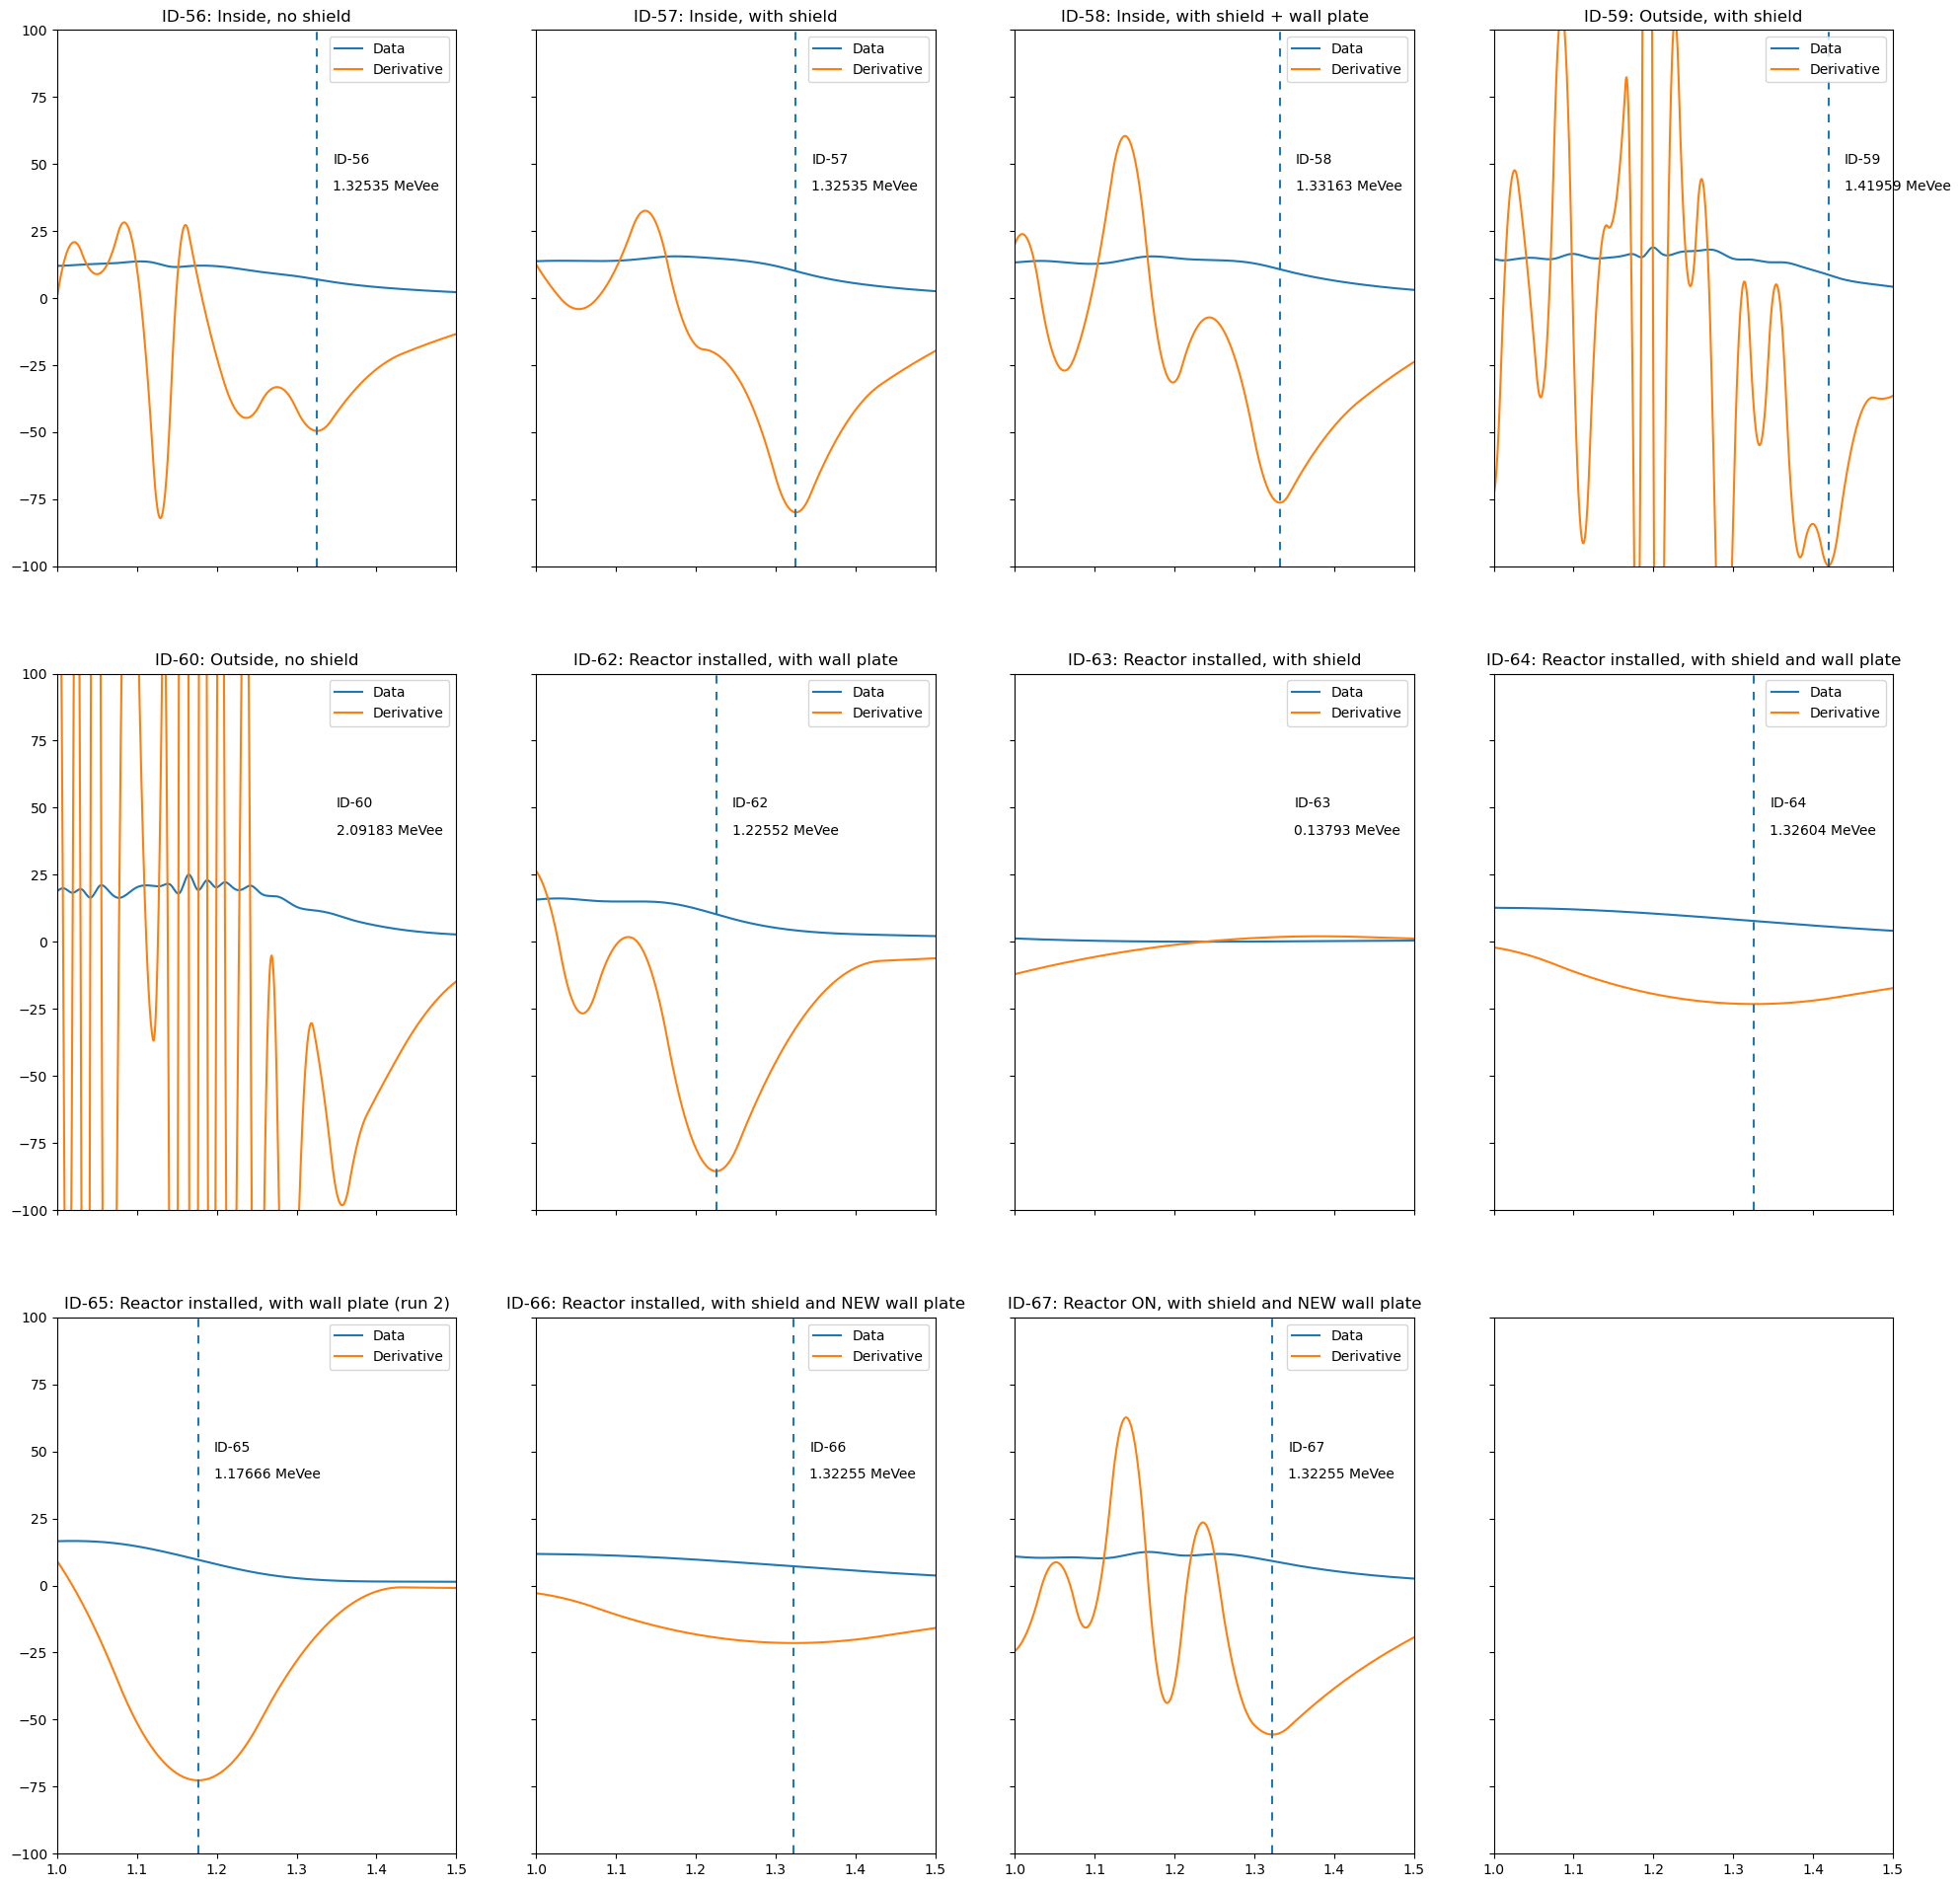

In [37]:
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(24,24))
row1, row2, row3 = axs
all_axs = [*row1, *row2, *row3]
for i, (exp_name, plot_series) in enumerate(plot_data.items()):
    ax = all_axs[i]
    ax.set_title(f"{exp_name}: {plot_series['exp_description']}")
    ax.plot(plot_series['x'], plot_series['y'], label="Data")
    ax.plot(plot_series['x'], plot_series['y_deriv'], label="Derivative")
    compton_edge = plot_series['compton_edge']
    ax.axvline(compton_edge, ymin=0, ymax=1, dashes=(4,4))
    text_x = compton_edge + 0.02 if 1.0<compton_edge<1.45 else 1.35
    text_y = 50
    ax.text(text_x, text_y, f"{exp_name}")
    ax.text(text_x, text_y - 10, f"{compton_edge} MeVee")
    ax.set_ylim(-100, 100)
    ax.set_xlim(1.0, 1.5)
    ax.legend()

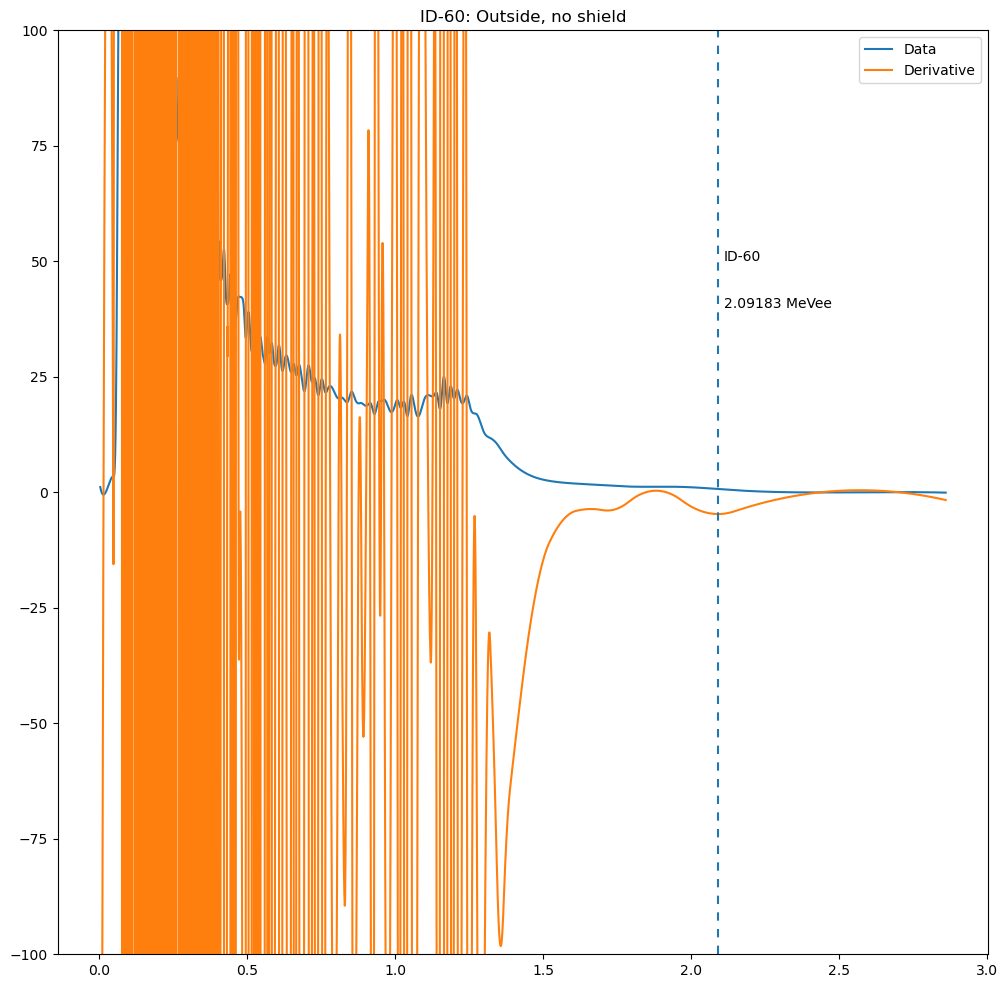

In [40]:
fig, ax = plt.subplots(figsize=(12,12))
# for i, (exp_name, plot_series) in enumerate(plot_data.items()):
#     ax = all_axs[i]
exp_name = "ID-60"
plot_series = plot_data[exp_name]
ax.set_title(f"{exp_name}: {plot_series['exp_description']}")
ax.plot(plot_series['x'], plot_series['y'], label="Data")
ax.plot(plot_series['x'], plot_series['y_deriv'], label="Derivative")
compton_edge = plot_series['compton_edge']
ax.axvline(compton_edge, ymin=0, ymax=1, dashes=(4,4))
# text_x = compton_edge + 0.02 if 1.0<compton_edge<1.45 else 1.35
text_x = compton_edge + 0.02
text_y = 50
ax.text(text_x, text_y, f"{exp_name}")
ax.text(text_x, text_y - 10, f"{compton_edge} MeVee")
ax.set_ylim(-100, 100)
# ax.set_xlim(1.0, 1.5)
ax.legend()

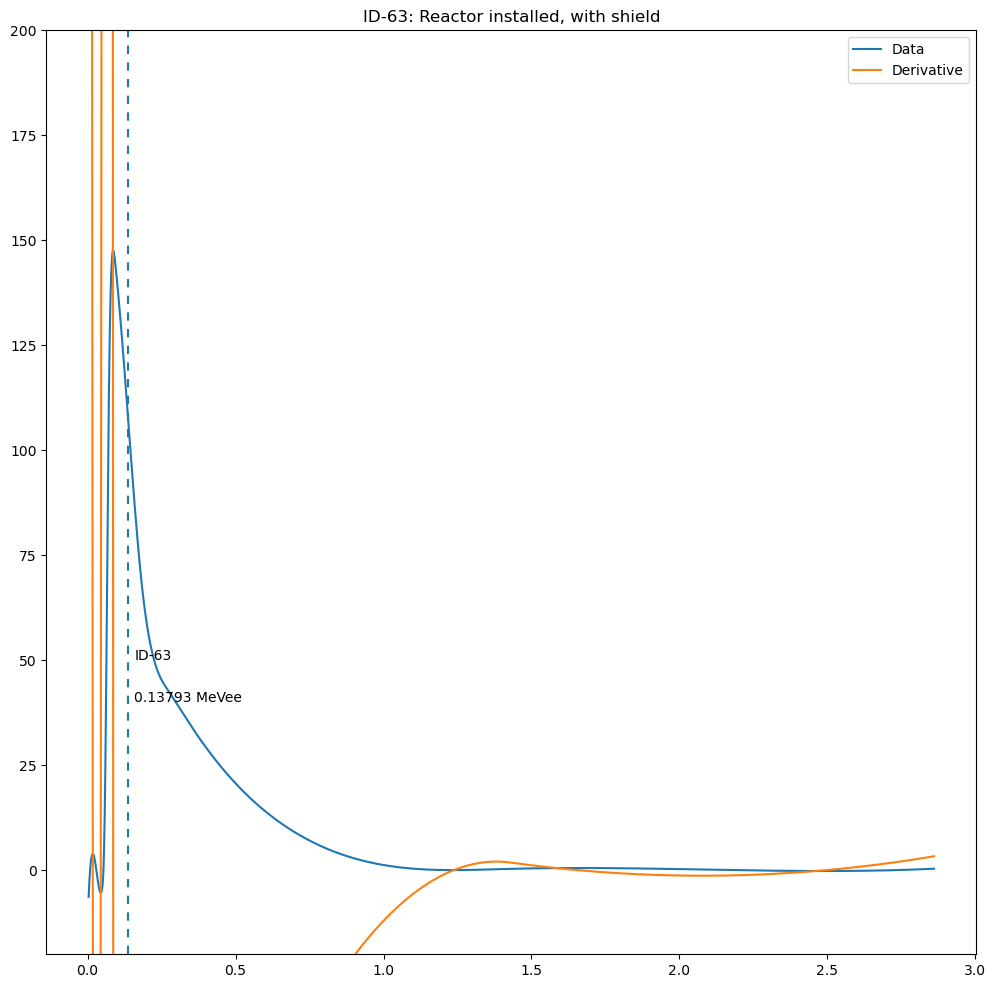

In [47]:
fig, ax = plt.subplots(figsize=(12,12))
# for i, (exp_name, plot_series) in enumerate(plot_data.items()):
#     ax = all_axs[i]
exp_name = "ID-63"
plot_series = plot_data[exp_name]
ax.set_title(f"{exp_name}: {plot_series['exp_description']}")
ax.plot(plot_series['x'], plot_series['y'], label="Data")
ax.plot(plot_series['x'], plot_series['y_deriv'], label="Derivative")
compton_edge = plot_series['compton_edge']
ax.axvline(compton_edge, ymin=0, ymax=1, dashes=(4,4))
# text_x = compton_edge + 0.02 if 1.0<compton_edge<1.45 else 1.35
text_x = compton_edge + 0.02
text_y = 50
ax.text(text_x, text_y, f"{exp_name}")
ax.text(text_x, text_y - 10, f"{compton_edge} MeVee")
ax.set_ylim(-20, 200)
# ax.set_xlim(1.0, 1.5)
ax.legend()

In [36]:
# check bin widths
EPSILON = 1e-19
stats = {}
for i, (exp_name, plot_series) in enumerate(plot_data.items()):
    bin_widths = np.diff(plot_series['x'])
    width_mean = bin_widths.mean()
    width_sd = bin_widths.std()
    stats[exp_name] = {'mean': width_mean, 'sd': width_sd, 'widths': bin_widths}
equal_means = [abs(x - stats['ID-56']['mean']) <= EPSILON 
               for x in [
                   v['mean'] for v in stats.values()
               ]]
equal_sds = [abs(x - stats['ID-56']['sd']) <= EPSILON
             for x in [
                 v['sd'] for v in stats.values()
             ]]
same_widths = []
exp_widths = list(zip(*[list(v['widths']) for v in stats.values()]))
for width in exp_widths:
    same_widths.append(
        all(
            [abs(x - width[0]) <= EPSILON 
             for x in width]
        ))
print(all(equal_means))
print(all(equal_sds))
print(all(same_widths))

True
True
True
